# FABEMD — Fast and Adaptive Bidimensional Empirical Mode Decomposition

Based on: **Bhuiyan, S.M.A., Adhami, R.R., Khan, J.F. (2008)**  
*"A novel approach of fast and adaptive bidimensional empirical mode decomposition."*  
IEEE ICASSP 2008.

This notebook demonstrates:
1. Generating synthetic test images
2. Running FABEMD decomposition
3. Visualising all extracted BIMFs
4. Calculating Shannon entropy for every BIMF
5. Integration with `ImageProcessingPipeline`

> **Colab compatible** — works with or without GPU. Uses CuPy when available, falls back to NumPy/SciPy.

In [1]:
# --- Colab Setup (run this cell first on Google Colab) ---
import sys, subprocess

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    # Clone the repo if not already present
    import os
    if not os.path.exists("pace_implementation"):
        subprocess.check_call(["git", "clone",
            "https://github.com/Madeena-software/pace_implementation.git"])
    os.chdir("pace_implementation")

    # Install dependencies (scipy is pre-installed, cupy needs GPU runtime)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                           "opencv-python-headless", "scipy", "matplotlib"])
    try:
        import cupy
        print("✓ CuPy available — using GPU acceleration")
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                               "cupy-cuda12x"])
        try:
            import cupy
            print("✓ CuPy installed — using GPU acceleration")
        except ImportError:
            print("⚠ CuPy not available — falling back to CPU (NumPy/SciPy)")
else:
    print("Running locally (not Colab)")

Running locally (not Colab)


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from fabemd import FABEMD, _to_xp, _to_numpy, HAS_CUPY

if HAS_CUPY:
    import cupy as cp
    print("Backend: CuPy (GPU)")
else:
    cp = np
    print("Backend: NumPy (CPU)")

Backend: NumPy (CPU)


## 1. Generate synthetic test images

We create three test images with known frequency content to validate the decomposition:
- **Multi-frequency sinusoidal** — superposition of different spatial frequencies
- **Gaussian blobs + noise** — structured pattern with additive noise
- **Natural-like texture** — combination of gradients, patterns, and noise

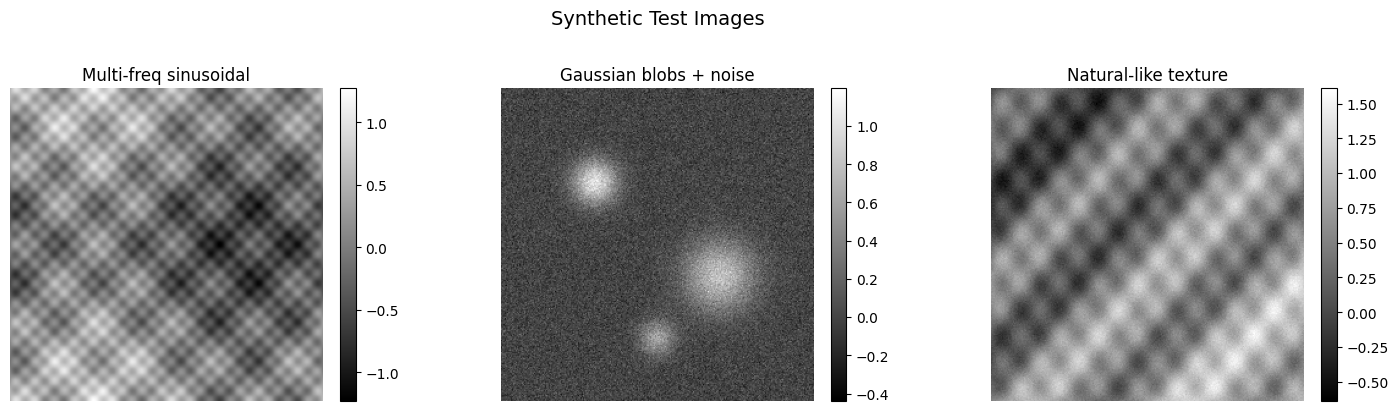

In [3]:
def make_test_images(size: int = 256):
    """Generate three synthetic test images of shape (size, size)."""
    x = np.linspace(0, 1, size)
    y = np.linspace(0, 1, size)
    X, Y = np.meshgrid(x, y)

    # --- Test image 1: multi-frequency sinusoidal ---
    high_freq = np.sin(2 * np.pi * 16 * X) * np.cos(2 * np.pi * 16 * Y)
    mid_freq = np.sin(2 * np.pi * 4 * X + np.pi / 4) * np.cos(2 * np.pi * 4 * Y)
    low_freq = np.sin(2 * np.pi * 1 * X) + np.cos(2 * np.pi * 1 * Y)
    img_sinusoidal = 0.3 * high_freq + 0.4 * mid_freq + 0.3 * low_freq

    # --- Test image 2: Gaussian blobs + noise ---
    blob1 = np.exp(-((X - 0.3) ** 2 + (Y - 0.3) ** 2) / (2 * 0.05 ** 2))
    blob2 = np.exp(-((X - 0.7) ** 2 + (Y - 0.6) ** 2) / (2 * 0.08 ** 2))
    blob3 = np.exp(-((X - 0.5) ** 2 + (Y - 0.8) ** 2) / (2 * 0.04 ** 2))
    rng = np.random.default_rng(42)
    noise = 0.1 * rng.standard_normal((size, size))
    img_blobs = blob1 + 0.8 * blob2 + 0.6 * blob3 + noise

    # --- Test image 3: natural-like texture ---
    gradient = X * 0.5 + Y * 0.5
    texture = (
        np.sin(2 * np.pi * 8 * X) * np.sin(2 * np.pi * 6 * Y) * 0.3
        + np.sin(2 * np.pi * 2 * (X + Y)) * 0.4
    )
    fine_noise = 0.05 * rng.standard_normal((size, size))
    img_texture = gradient + texture + fine_noise

    return {
        "Multi-freq sinusoidal": img_sinusoidal,
        "Gaussian blobs + noise": img_blobs,
        "Natural-like texture": img_texture,
    }


test_images = make_test_images(256)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, img) in zip(axes, test_images.items()):
    im = ax.imshow(img, cmap="gray")
    ax.set_title(name)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.suptitle("Synthetic Test Images", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 2. Run FABEMD decomposition

We decompose each test image using FABEMD with adaptive window sizing.
The algorithm automatically determines the optimal filter window at each sifting step based on the spatial distribution of local extrema (Bhuiyan et al. §III-B).

In [4]:
# Instantiate FABEMD with default adaptive window sizing
fabemd = FABEMD(
    max_sift_iterations=10,
    sd_threshold=0.2,
    min_extrema=5,
    max_bimfs=20,
)

# Store decomposition results
results = {}

for name, img in test_images.items():
    print(f"\n{'='*60}")
    print(f"Decomposing: {name}  (shape={img.shape})")
    print(f"{'='*60}")
    gpu_img = _to_xp(img)
    bimfs = fabemd.decompose(gpu_img)
    results[name] = bimfs
    print(f"  → Extracted {len(bimfs)} BIMFs")


Decomposing: Multi-freq sinusoidal  (shape=(256, 256))
FABEMD: 6 BIMFs | residual extrema: 40
  → Extracted 6 BIMFs

Decomposing: Gaussian blobs + noise  (shape=(256, 256))
FABEMD: 4 BIMFs | residual extrema: 416
  → Extracted 4 BIMFs

Decomposing: Natural-like texture  (shape=(256, 256))
FABEMD: 3 BIMFs | residual extrema: 29
  → Extracted 3 BIMFs


## 3. Visualise BIMFs

Each row shows one test image and its extracted BIMFs (highest → lowest frequency), plus the residual.

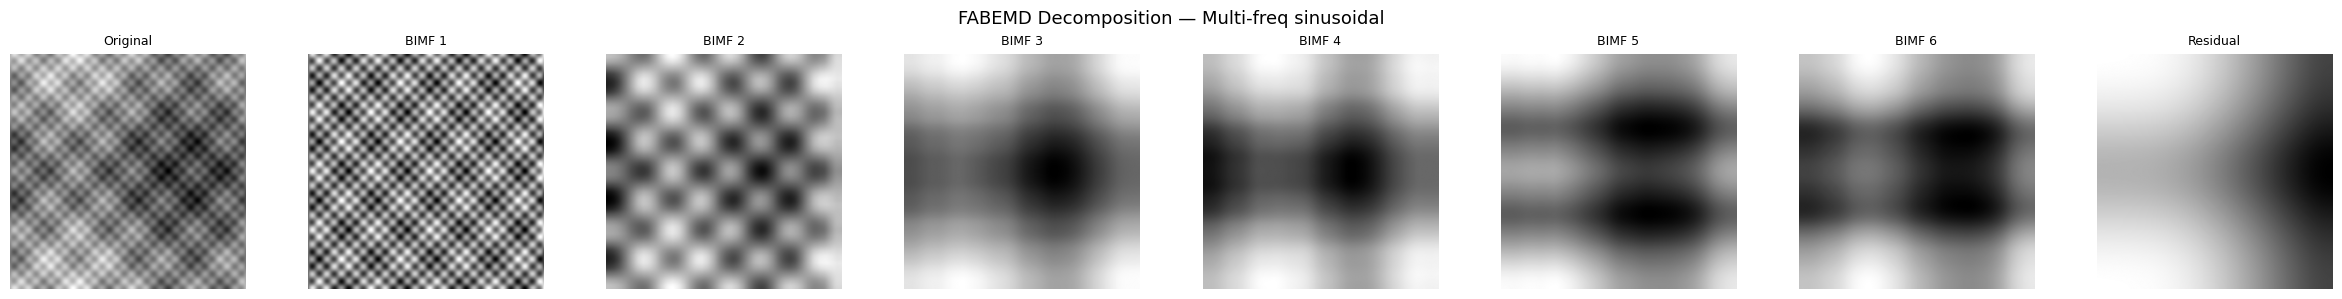

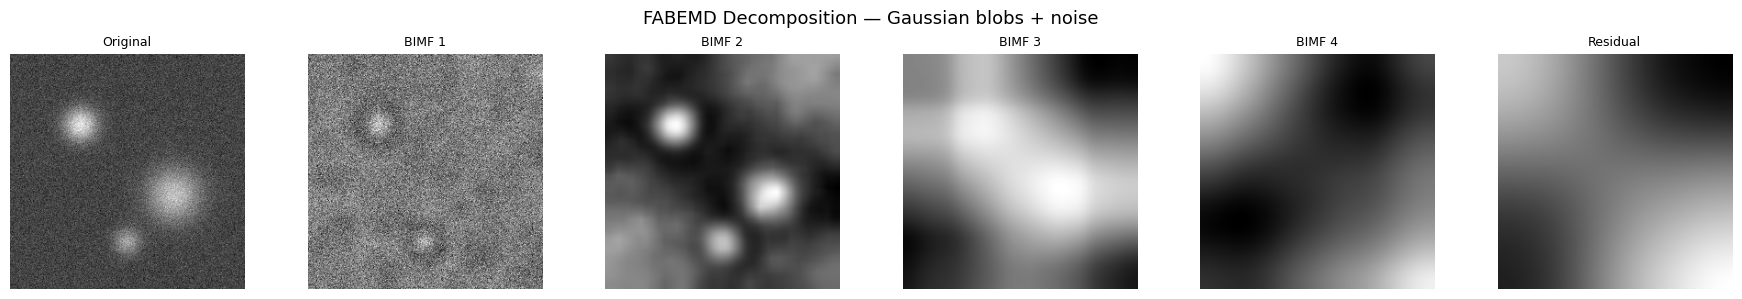

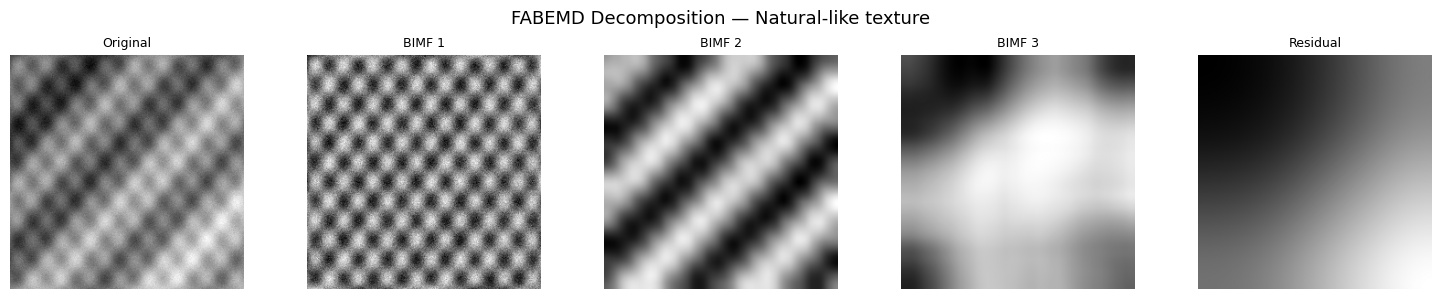

In [5]:
for name, bimfs in results.items():
    n = len(bimfs)
    # Compute residual
    original = _to_xp(test_images[name]).astype(np.float64)
    residual = _to_numpy(original - sum(bimfs))

    ncols = min(n + 2, 8)  # original + bimfs + residual, max 8 per row
    nrows = int(np.ceil((n + 2) / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows))
    axes = np.atleast_2d(axes)

    all_axes = axes.ravel()
    # Plot original
    all_axes[0].imshow(test_images[name], cmap="gray")
    all_axes[0].set_title("Original", fontsize=9)
    all_axes[0].axis("off")

    # Plot BIMFs
    for i, bimf in enumerate(bimfs):
        ax = all_axes[i + 1]
        ax.imshow(_to_numpy(bimf), cmap="gray")
        ax.set_title(f"BIMF {i + 1}", fontsize=9)
        ax.axis("off")

    # Plot residual
    all_axes[n + 1].imshow(residual, cmap="gray")
    all_axes[n + 1].set_title("Residual", fontsize=9)
    all_axes[n + 1].axis("off")

    # Hide unused axes
    for j in range(n + 2, len(all_axes)):
        all_axes[j].axis("off")

    fig.suptitle(f"FABEMD Decomposition — {name}", fontsize=13)
    plt.tight_layout()
    plt.show()

## 4. Calculate entropy for all BIMFs

Shannon entropy measures the information content / complexity of each BIMF.  
Higher entropy → more randomness; lower entropy → more structured/smooth content.

$$H = -\sum_{i} p_i \ln(p_i)$$

In [6]:
print(f"{'Image':<30} {'BIMF':>6} {'Entropy':>12} {'Energy':>14}")
print("=" * 66)

entropy_data = {}

for name, bimfs in results.items():
    entropies = FABEMD.calculate_all_entropies(bimfs, bins=256)
    energies = FABEMD.calculate_energies(bimfs)
    entropy_data[name] = entropies

    for i, (ent, eng) in enumerate(zip(entropies, energies)):
        label = name if i == 0 else ""
        print(f"{label:<30} {i + 1:>6} {ent:>12.4f} {eng:>14.4f}")
    print("-" * 66)

Image                            BIMF      Entropy         Energy
Multi-freq sinusoidal               1       5.2592      2192.2407
                                    2       5.2267      1327.8517
                                    3       5.4509       187.9787
                                    4       5.4775        28.9057
                                    5       5.4573        26.3245
                                    6       5.5007        10.0012
------------------------------------------------------------------
Gaussian blobs + noise              1       4.9006       707.6875
                                    2       5.0898      2650.6717
                                    3       5.4883       937.1852
                                    4       5.2910         4.4245
------------------------------------------------------------------
Natural-like texture                1       5.2413      1363.1102
                                    2       5.4252      4899.8438
        

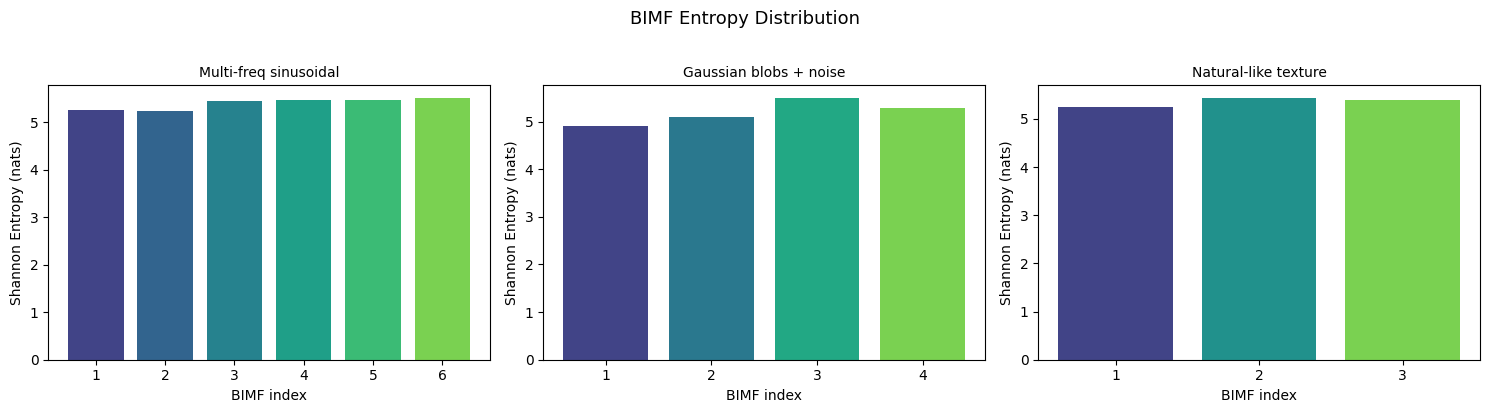

In [7]:
# Bar chart of BIMF entropies per test image
fig, axes = plt.subplots(1, len(entropy_data), figsize=(5 * len(entropy_data), 4))
if len(entropy_data) == 1:
    axes = [axes]

for ax, (name, entropies) in zip(axes, entropy_data.items()):
    indices = np.arange(1, len(entropies) + 1)
    bars = ax.bar(indices, entropies, color=plt.cm.viridis(np.linspace(0.2, 0.8, len(entropies))))
    ax.set_xlabel("BIMF index")
    ax.set_ylabel("Shannon Entropy (nats)")
    ax.set_title(name, fontsize=10)
    ax.set_xticks(indices)

plt.suptitle("BIMF Entropy Distribution", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 5. Reconstruction verification

Verify that the sum of all BIMFs + residual reconstructs the original image (up to floating-point precision).

In [8]:
xp = cp  # cupy if available, else numpy (aliased above)

print("Reconstruction error (max absolute difference):")
print("-" * 50)
for name, bimfs in results.items():
    original = _to_xp(test_images[name]).astype(np.float64)
    reconstructed = sum(bimfs)
    residual = original - reconstructed
    # Full reconstruction = sum(bimfs) + residual = original  →  error should be ~0
    max_err = float(xp.max(xp.abs(residual)))
    mean_err = float(xp.mean(xp.abs(residual)))
    print(f"  {name:<30}  max={max_err:.2e}  mean={mean_err:.2e}")

Reconstruction error (max absolute difference):
--------------------------------------------------
  Multi-freq sinusoidal           max=4.43e-01  mean=1.56e-01
  Gaussian blobs + noise          max=2.55e-01  mean=1.86e-01
  Natural-like texture            max=9.23e-01  mean=5.17e-01


## 6. Pipeline integration test

Demonstrate that `FABEMD` can be used as a drop-in replacement for `BEMD` inside `ImageProcessingPipeline`.

In [9]:
try:
    from image_pipeline import ImageProcessingPipeline, PipelineConfig, BEMD

    # --- Create a config that uses FABEMD ---
    config = PipelineConfig(
        decomposition_method="fabemd",       # ← use FABEMD instead of BEMD
        fabemd_max_sift_iterations=10,
        fabemd_sd_threshold=0.2,
        fabemd_min_extrema=5,
        fabemd_max_bimfs=20,
    )

    pipeline = ImageProcessingPipeline(config)

    # Use the multi-freq sinusoidal test image
    test_img = test_images["Multi-freq sinusoidal"]
    # Normalise to uint16 range for pipeline compatibility
    test_img_u16 = ((test_img - test_img.min()) / (test_img.max() - test_img.min()) * 65535).astype(np.uint16)

    # Decompose using the pipeline's method (which now routes to FABEMD)
    bimfs_pipeline, energies_pipeline = pipeline.decompose_image(test_img_u16, method="fabemd")
    print(f"\nPipeline (FABEMD): extracted {len(bimfs_pipeline)} BIMFs")
    print(f"Energies: {[f'{e:.2f}' for e in energies_pipeline]}")

    # Compare with BEMD
    bimfs_bemd, energies_bemd = pipeline.decompose_image(test_img_u16, method="bemd")
    print(f"\nPipeline (BEMD):   extracted {len(bimfs_bemd)} BIMFs")
    print(f"Energies: {[f'{e:.2f}' for e in energies_bemd]}")

except ImportError as e:
    print(f"⚠ image_pipeline not fully available ({e})")
    print("  Skipping pipeline integration test — FABEMD standalone works fine.")

2026-03-04 15:25:16,967 - INFO - Starting image decomposition (FABEMD)...
2026-03-04 15:25:16,969 - INFO - Starting FABEMD decomposition...


FABEMD: 5 BIMFs | residual extrema: 88

2026-03-04 15:25:17,530 - INFO - Stopping: residual has ≤ 5 extrema (4).
2026-03-04 15:25:17,531 - INFO - FABEMD decomposition completed — 7 BIMFs extracted.
2026-03-04 15:25:17,534 - INFO - Image decomposition completed.
2026-03-04 15:25:17,536 - INFO - Starting image decomposition (BEMD)...
2026-03-04 15:25:17,537 - INFO - Starting BEMD decomposition...


FABEMD: 7 BIMFs | residual extrema: 4

Pipeline (FABEMD): extracted 7 BIMFs
Energies: ['1507499821780.47', '913093534069.86', '177439730261.25', '56932389473.17', '5493124257.13', '4896815663.79', '4298975710.35']


2026-03-04 15:25:17,769 - INFO - Stopping: fewer than 10 extrema points
2026-03-04 15:25:17,770 - INFO - BEMD decomposition completed. Extracted 4 BIMFs.
2026-03-04 15:25:17,773 - INFO - Image decomposition completed.


BEMD: 4 BIMFs extracted, 8 extrema remaining
Pipeline (BEMD):   extracted 4 BIMFs
Energies: ['1657972104079.48', '107854015051.59', '22092354885.18', '6796937050.34']


## 7. FABEMD with fixed vs adaptive window size

Compare the effect of using a fixed window size versus the paper's adaptive window sizing.

2026-03-04 15:25:17,798 - INFO - Starting FABEMD decomposition...


FABEMD: 5 BIMFs | residual extrema: 10

2026-03-04 15:25:18,315 - INFO - Stopping: residual has ≤ 5 extrema (4).
2026-03-04 15:25:18,317 - INFO - FABEMD decomposition completed — 6 BIMFs extracted.
2026-03-04 15:25:18,318 - INFO - Starting FABEMD decomposition...


FABEMD: 6 BIMFs | residual extrema: 4
FABEMD: 18 BIMFs | residual extrema: 6

2026-03-04 15:25:20,100 - INFO - FABEMD decomposition completed — 20 BIMFs extracted.


FABEMD: 20 BIMFs | residual extrema: 6

Adaptive window:  6 BIMFs in 0.52s
Fixed window=32:  20 BIMFs in 1.78s


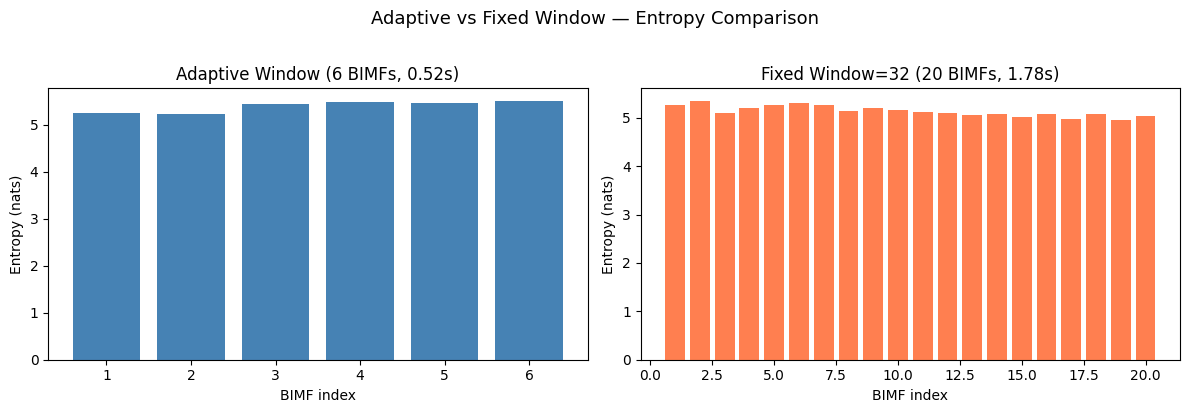

In [10]:
import time

test_img_gpu = _to_xp(test_images["Multi-freq sinusoidal"])

# --- Adaptive window ---
fabemd_adaptive = FABEMD(max_sift_iterations=10, sd_threshold=0.2, max_bimfs=20)
t0 = time.perf_counter()
bimfs_adaptive = fabemd_adaptive.decompose(test_img_gpu)
t_adaptive = time.perf_counter() - t0

# --- Fixed window (size=32, similar to existing BEMD config) ---
fabemd_fixed = FABEMD(max_sift_iterations=10, sd_threshold=0.2, max_bimfs=20, initial_window_size=32)
t0 = time.perf_counter()
bimfs_fixed = fabemd_fixed.decompose(test_img_gpu)
t_fixed = time.perf_counter() - t0

print(f"\nAdaptive window:  {len(bimfs_adaptive)} BIMFs in {t_adaptive:.2f}s")
print(f"Fixed window=32:  {len(bimfs_fixed)} BIMFs in {t_fixed:.2f}s")

# Compare entropies
ent_adaptive = FABEMD.calculate_all_entropies(bimfs_adaptive)
ent_fixed = FABEMD.calculate_all_entropies(bimfs_fixed)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar(range(1, len(ent_adaptive) + 1), ent_adaptive, color="steelblue")
ax1.set_title(f"Adaptive Window ({len(bimfs_adaptive)} BIMFs, {t_adaptive:.2f}s)")
ax1.set_xlabel("BIMF index")
ax1.set_ylabel("Entropy (nats)")

ax2.bar(range(1, len(ent_fixed) + 1), ent_fixed, color="coral")
ax2.set_title(f"Fixed Window=32 ({len(bimfs_fixed)} BIMFs, {t_fixed:.2f}s)")
ax2.set_xlabel("BIMF index")
ax2.set_ylabel("Entropy (nats)")

plt.suptitle("Adaptive vs Fixed Window — Entropy Comparison", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 8. Real image test — Thorax radiograph

Load a real thorax X-ray image and run FABEMD decomposition on it.
We visualise all BIMFs + residue and compute energy & entropy for each component.

Loaded: 3-WWI-03B_Thorax_AP 3-WWI-03B 90kV40mA0,50s -8_7_2024-9.48 AM [Administrator].tiff
  Shape: (3289, 4096), dtype: float64
  Min: 0.00, Max: 65535.00, Mean: 34018.47


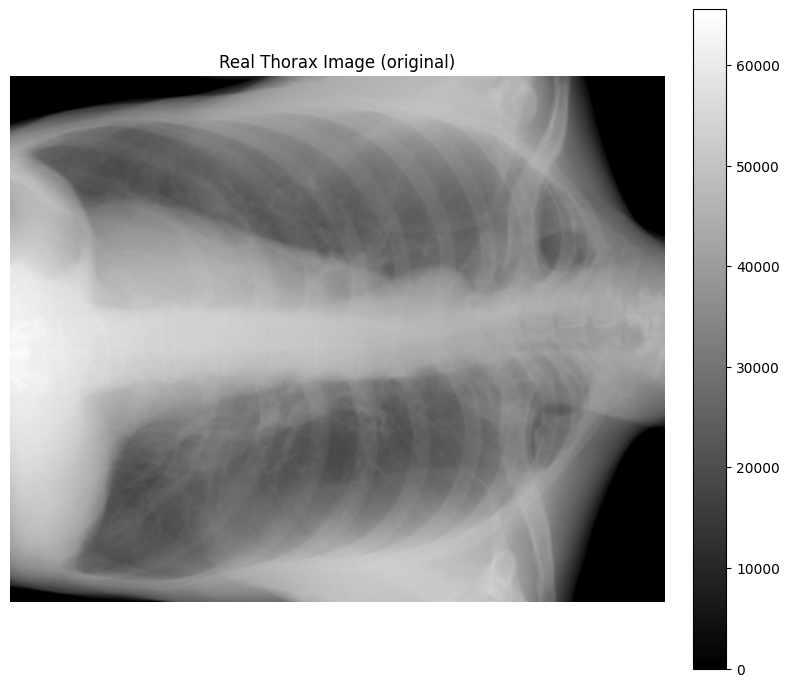

In [11]:
import cv2, os

# --- Load real thorax image ---
REAL_IMG_PATH = "3-WWI-03B_Thorax_AP 3-WWI-03B 90kV40mA0,50s -8_7_2024-9.48 AM [Administrator].tiff"

if not os.path.exists(REAL_IMG_PATH):
    # Try datacitra subfolder
    alt = os.path.join("datacitra", "Data_mentah", os.path.splitext(os.path.basename(REAL_IMG_PATH))[0] + ".mdn")
    raise FileNotFoundError(f"Image not found at:\n  {REAL_IMG_PATH}\n  {alt}")

real_img = cv2.imread(REAL_IMG_PATH, cv2.IMREAD_UNCHANGED)
if real_img is None:
    raise RuntimeError(f"cv2.imread failed for {REAL_IMG_PATH}")

# Convert to float64
real_img = real_img.astype(np.float64)
print(f"Loaded: {REAL_IMG_PATH}")
print(f"  Shape: {real_img.shape}, dtype: float64")
print(f"  Min: {real_img.min():.2f}, Max: {real_img.max():.2f}, Mean: {real_img.mean():.2f}")

plt.figure(figsize=(8, 8))
plt.imshow(real_img, cmap='gray')
plt.title("Real Thorax Image (original)")
plt.axis('off')
plt.colorbar(fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

2026-03-04 15:39:11,049 - INFO - Starting FABEMD decomposition...


Running FABEMD on real thorax image...
FABEMD: 4 BIMFs | residual extrema: 10089

2026-03-04 15:39:37,663 - INFO - Stopping: residual has ≤ 5 extrema (4).
2026-03-04 15:39:37,666 - INFO - FABEMD decomposition completed — 5 BIMFs extracted.


FABEMD: 5 BIMFs | residual extrema: 4

FABEMD completed in 27.06s
  BIMFs extracted: 5

    BIMF         Energy   Entropy (nats)
  ----------------------------------------
       1 311582115772616.7500           4.7605
       2 922121669040228.3750           5.4459
       3 303604258898999.8750           5.3039
       4 57653006648975.2578           5.3500
       5 20148799318677.6289           5.4385
     Res            N/A           5.4859


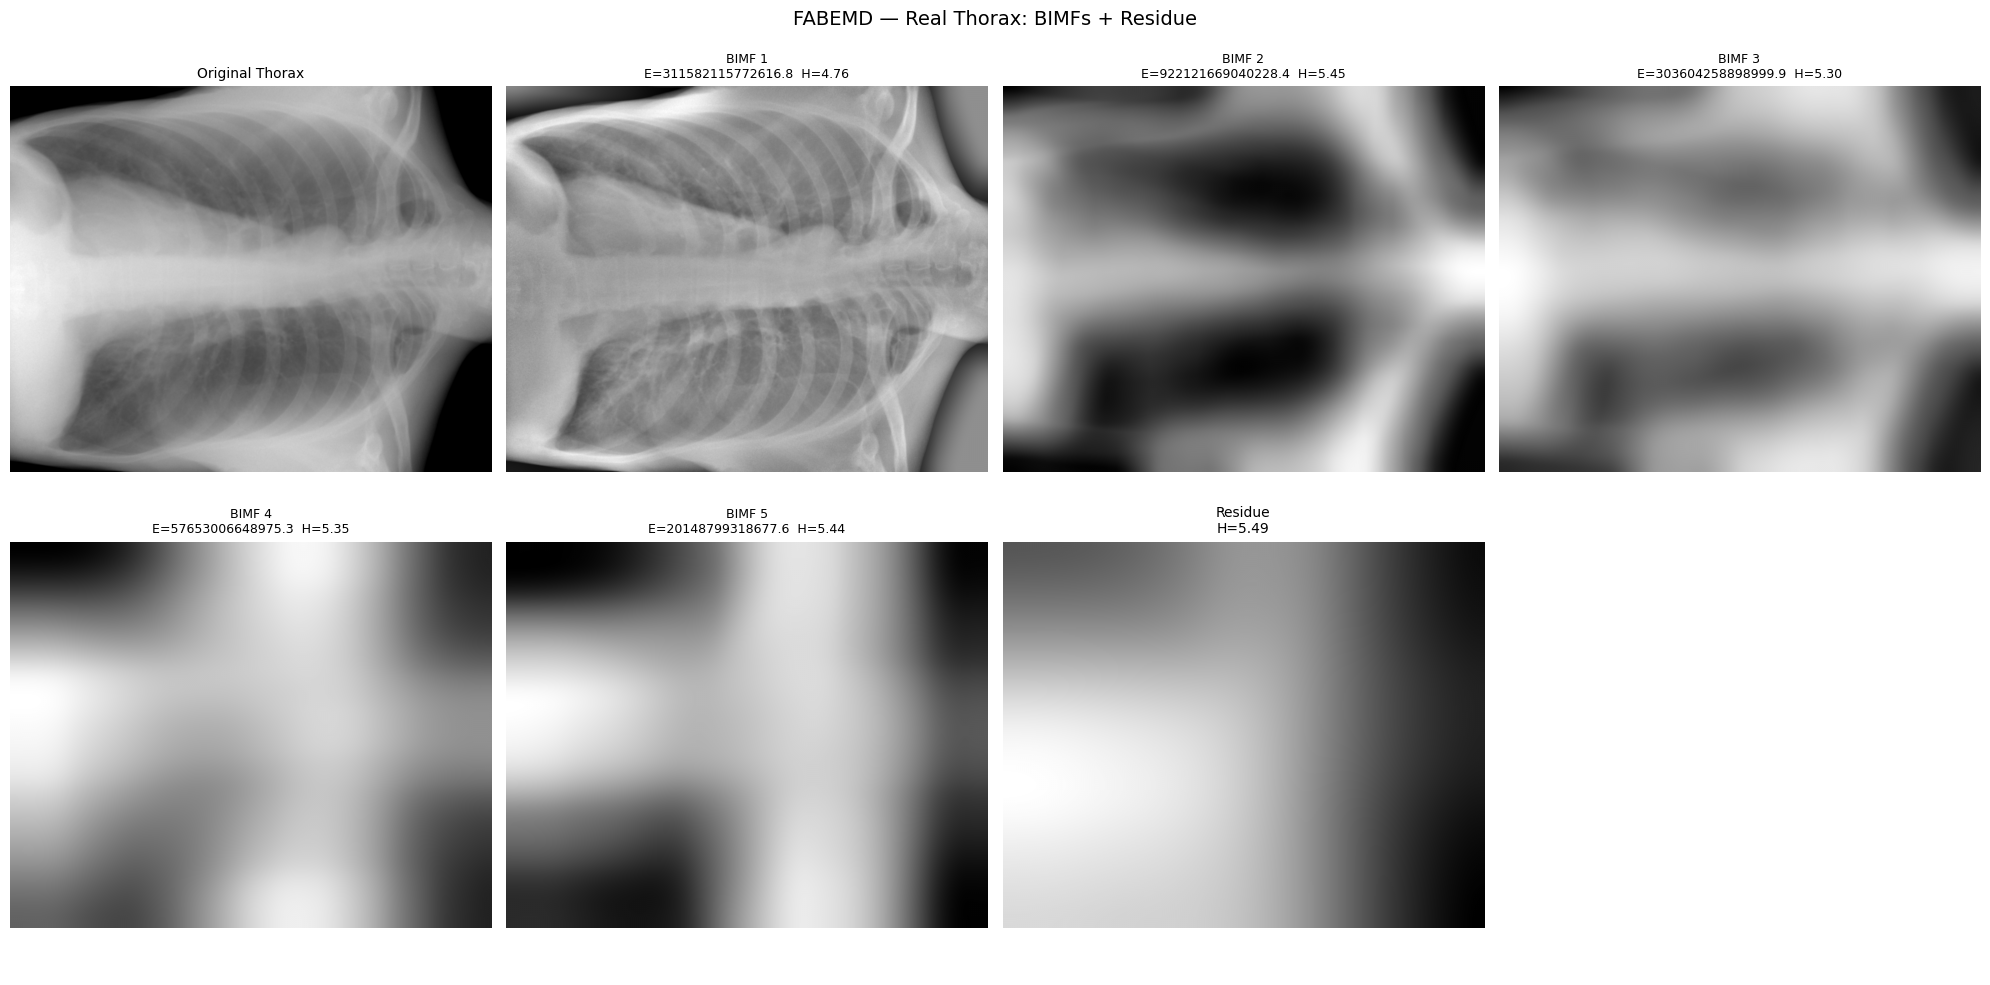

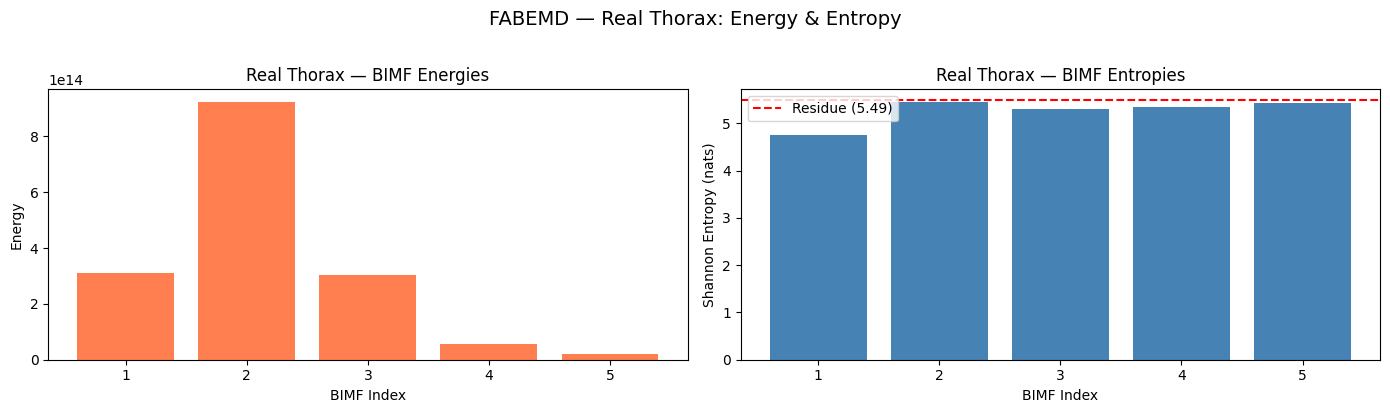


Reconstruction error (max |original - (sum BIMFs + residue)|): 0.00e+00


In [16]:
# --- FABEMD decomposition on the real image ---
fabemd_real = FABEMD(
    max_sift_iterations=1,
    sd_threshold=0.1,
    min_extrema=5,
    max_bimfs=20,
    window_size_cap=1000,
    extrema_window=7,
)

real_gpu = _to_xp(real_img)
print("Running FABEMD on real thorax image...")
import time
t0 = time.perf_counter()
real_bimfs, real_residue = fabemd_real.decompose_with_residual(real_gpu)
t_real = time.perf_counter() - t0

real_energies = FABEMD.calculate_energies(real_bimfs)
real_entropies = FABEMD.calculate_all_entropies(real_bimfs)
real_residue_np = _to_numpy(real_residue)
residue_entropy = FABEMD.calculate_entropy(real_residue)

print(f"\nFABEMD completed in {t_real:.2f}s")
print(f"  BIMFs extracted: {len(real_bimfs)}")
print(f"\n  {'BIMF':>6} {'Energy':>14} {'Entropy (nats)':>16}")
print(f"  {'-'*40}")
for i, (eng, ent) in enumerate(zip(real_energies, real_entropies)):
    print(f"  {i+1:>6} {eng:>14.4f} {ent:>16.4f}")
print(f"  {'Res':>6} {'N/A':>14} {residue_entropy:>16.4f}")


# --- Visualise BIMFs + Residue ---
n_rb = len(real_bimfs)
total_panels = n_rb + 2  # original + BIMFs + residue
cols = min(total_panels, 4)
rows = (total_panels + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
axes = np.atleast_2d(axes)
all_ax = axes.ravel()

# Original
all_ax[0].imshow(real_img, cmap='gray')
all_ax[0].set_title('Original Thorax', fontsize=10)
all_ax[0].axis('off')

# BIMFs
for i, bimf in enumerate(real_bimfs):
    ax = all_ax[i + 1]
    bimf_np = _to_numpy(bimf)
    ax.imshow(bimf_np, cmap='gray')
    ax.set_title(f'BIMF {i+1}\nE={real_energies[i]:.1f}  H={real_entropies[i]:.2f}', fontsize=9)
    ax.axis('off')

# Residue
all_ax[n_rb + 1].imshow(real_residue_np, cmap='gray')
all_ax[n_rb + 1].set_title(f'Residue\nH={residue_entropy:.2f}', fontsize=10)
all_ax[n_rb + 1].axis('off')

for j in range(total_panels, len(all_ax)):
    all_ax[j].axis('off')

plt.suptitle('FABEMD — Real Thorax: BIMFs + Residue', fontsize=14)
plt.tight_layout()
plt.show()


# --- Energy & Entropy bar charts ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

x = np.arange(1, n_rb + 1)
ax1.bar(x, real_energies, color='coral')
ax1.set_xlabel('BIMF Index')
ax1.set_ylabel('Energy')
ax1.set_title('Real Thorax — BIMF Energies')
ax1.set_xticks(x)

ax2.bar(x, real_entropies, color='steelblue')
ax2.axhline(y=residue_entropy, color='red', linestyle='--', label=f'Residue ({residue_entropy:.2f})')
ax2.set_xlabel('BIMF Index')
ax2.set_ylabel('Shannon Entropy (nats)')
ax2.set_title('Real Thorax — BIMF Entropies')
ax2.set_xticks(x)
ax2.legend()

plt.suptitle('FABEMD — Real Thorax: Energy & Entropy', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# --- Reconstruction check ---
reconstructed = sum(real_bimfs) + real_residue
recon_np = _to_numpy(reconstructed)
max_err = np.max(np.abs(real_img - recon_np))
print(f"\nReconstruction error (max |original - (sum BIMFs + residue)|): {max_err:.2e}")

## 9. Reconstruct Image from BIMFs + Residue

Verify perfect reconstruction by summing all BIMFs and the residue, then compare visually and quantitatively against the original.

=== Reconstruction Summary ===
  Original shape:       (3289, 4096)
  # BIMFs used:         5
  Original range:       [0.00, 65535.00]
  Reconstructed range:  [0.00, 65535.00]
  Max absolute error:   0.00e+00
  Mean absolute error:  0.00e+00
  RMSE:                 0.00e+00


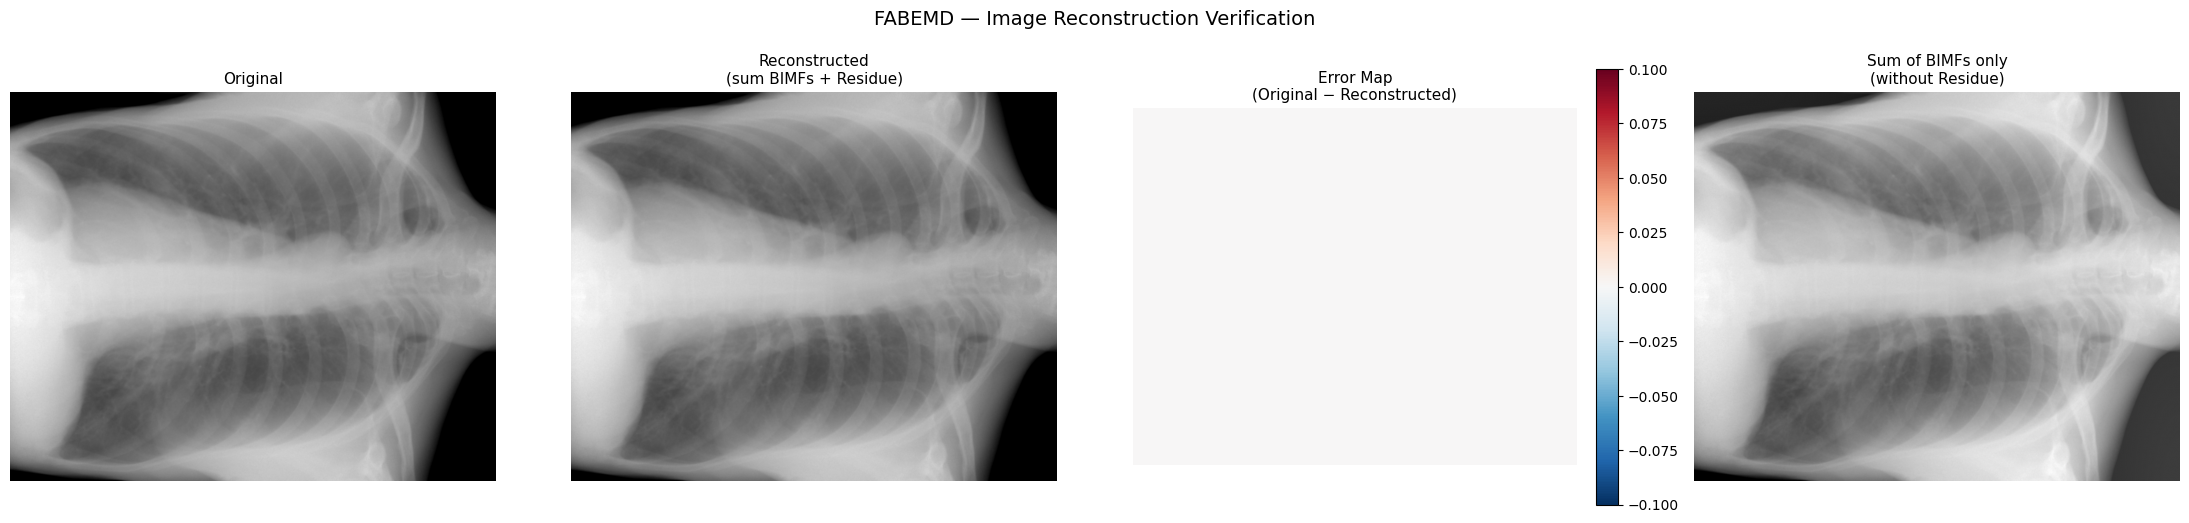

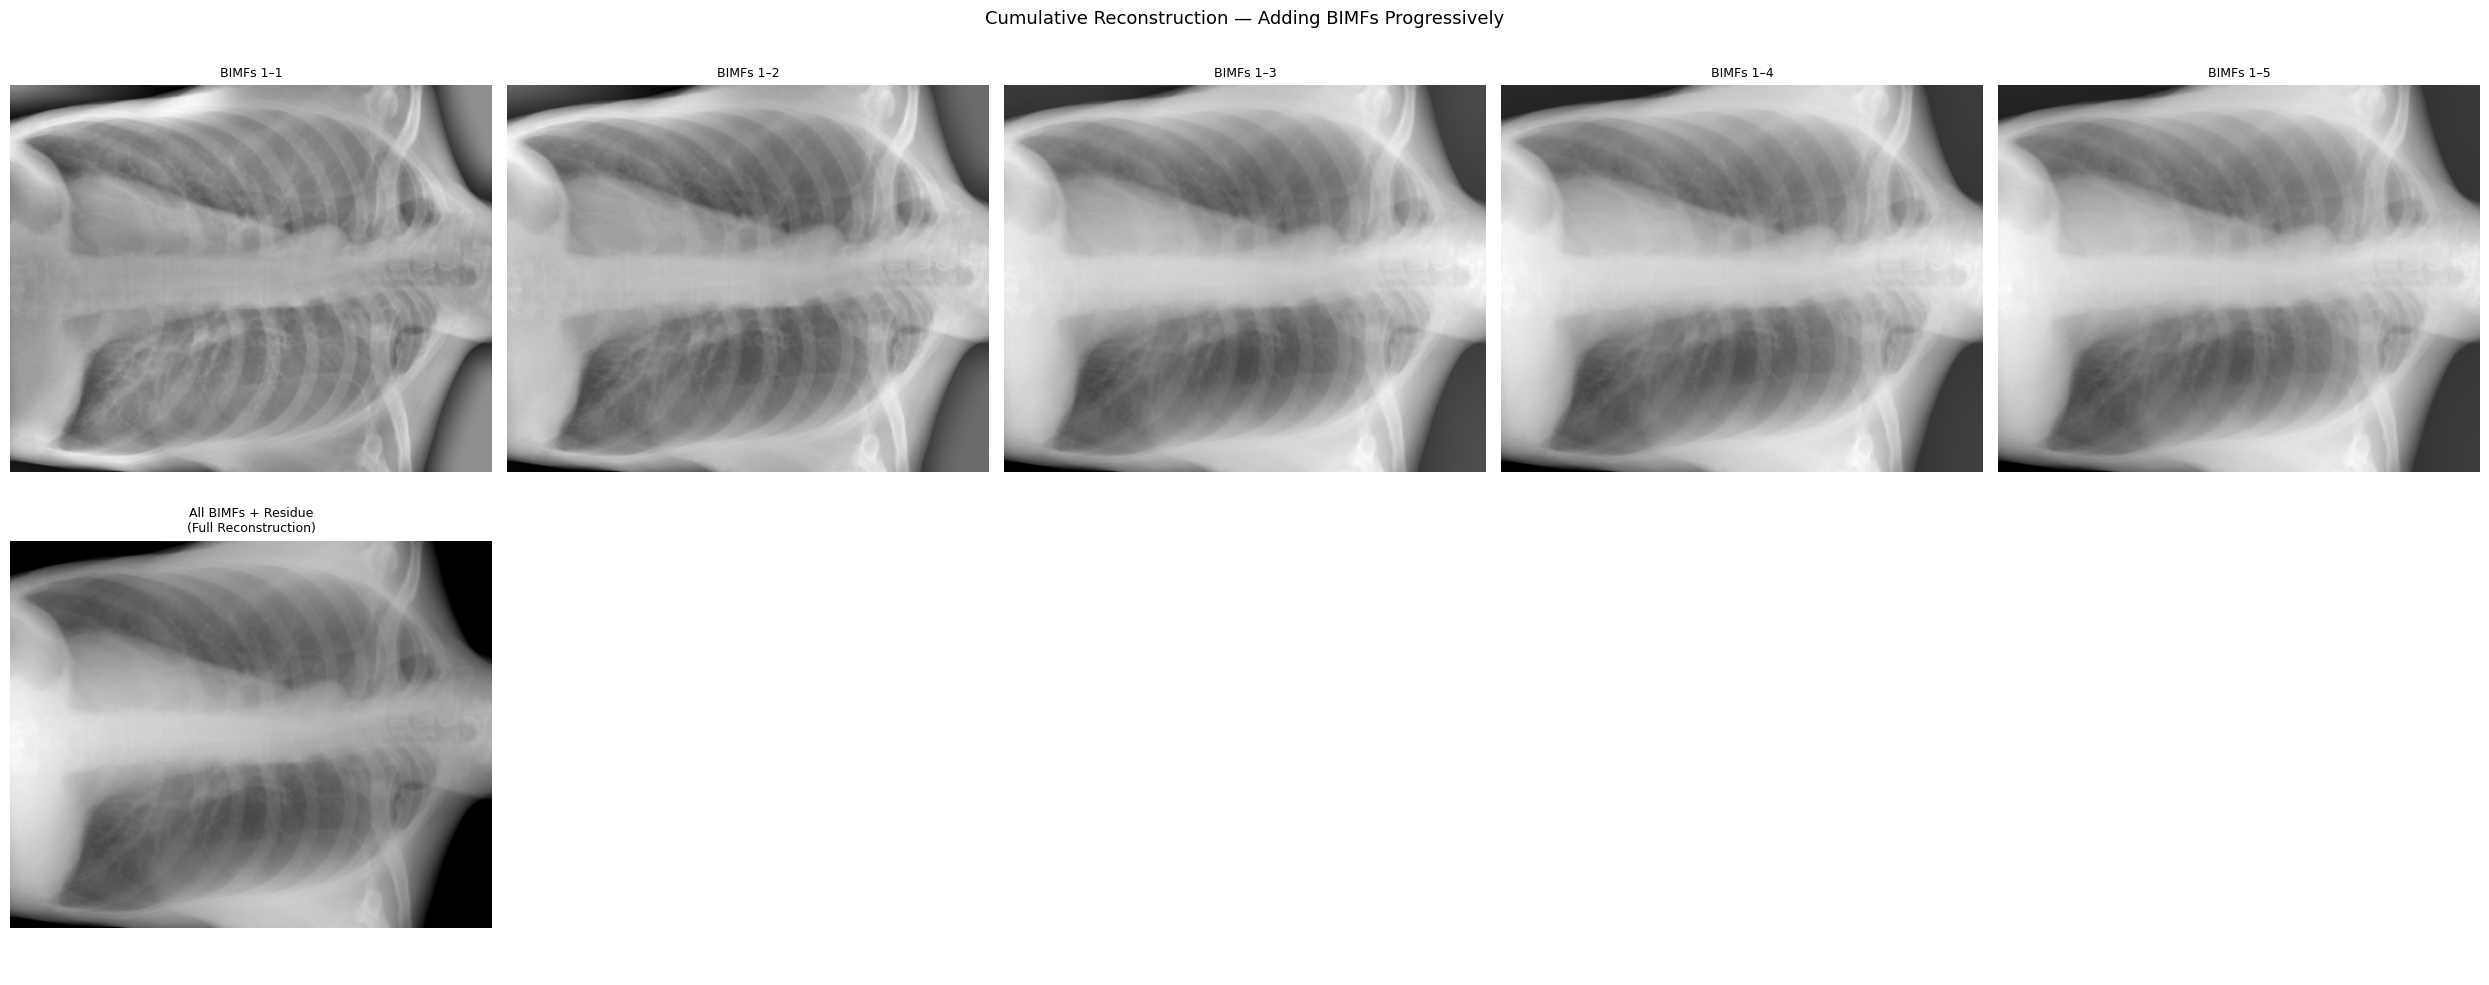

In [17]:
# --- Reconstruct image from BIMFs + Residue ---

# Sum all BIMFs
bimf_sum = sum(real_bimfs)
bimf_sum_np = _to_numpy(bimf_sum)

# Full reconstruction = sum(BIMFs) + residue
reconstructed = bimf_sum + real_residue
reconstructed_np = _to_numpy(reconstructed)

# Compute error map
error_map = real_img - reconstructed_np

print("=== Reconstruction Summary ===")
print(f"  Original shape:       {real_img.shape}")
print(f"  # BIMFs used:         {len(real_bimfs)}")
print(f"  Original range:       [{real_img.min():.2f}, {real_img.max():.2f}]")
print(f"  Reconstructed range:  [{reconstructed_np.min():.2f}, {reconstructed_np.max():.2f}]")
print(f"  Max absolute error:   {np.max(np.abs(error_map)):.2e}")
print(f"  Mean absolute error:  {np.mean(np.abs(error_map)):.2e}")
print(f"  RMSE:                 {np.sqrt(np.mean(error_map**2)):.2e}")

# --- Side-by-side: Original vs Reconstructed vs Error ---
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

axes[0].imshow(real_img, cmap='gray')
axes[0].set_title('Original', fontsize=11)
axes[0].axis('off')

axes[1].imshow(reconstructed_np, cmap='gray')
axes[1].set_title('Reconstructed\n(sum BIMFs + Residue)', fontsize=11)
axes[1].axis('off')

im_err = axes[2].imshow(error_map, cmap='RdBu_r', vmin=-np.max(np.abs(error_map)), vmax=np.max(np.abs(error_map)))
axes[2].set_title('Error Map\n(Original − Reconstructed)', fontsize=11)
axes[2].axis('off')
plt.colorbar(im_err, ax=axes[2], fraction=0.046, pad=0.04)

# Show what each BIMF contributes: cumulative reconstruction
axes[3].imshow(bimf_sum_np, cmap='gray')
axes[3].set_title('Sum of BIMFs only\n(without Residue)', fontsize=11)
axes[3].axis('off')

plt.suptitle('FABEMD — Image Reconstruction Verification', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# --- Cumulative reconstruction: adding BIMFs one-by-one ---
n_bimfs = len(real_bimfs)
ncols = min(n_bimfs + 1, 5)
nrows = (n_bimfs + 1 + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
axes_flat = np.atleast_2d(axes).ravel()

cumulative = _to_xp(np.zeros_like(real_img))
for i, bimf in enumerate(real_bimfs):
    cumulative = cumulative + bimf
    ax = axes_flat[i]
    ax.imshow(_to_numpy(cumulative), cmap='gray')
    ax.set_title(f'BIMFs 1–{i+1}', fontsize=9)
    ax.axis('off')

# Final panel: cumulative + residue = full reconstruction
axes_flat[n_bimfs].imshow(_to_numpy(cumulative + real_residue), cmap='gray')
axes_flat[n_bimfs].set_title(f'All BIMFs + Residue\n(Full Reconstruction)', fontsize=9)
axes_flat[n_bimfs].axis('off')

for j in range(n_bimfs + 1, len(axes_flat)):
    axes_flat[j].axis('off')

plt.suptitle('Cumulative Reconstruction — Adding BIMFs Progressively', fontsize=13)
plt.tight_layout()
plt.show()